## Mushroom (calssification), dataset evaluation report
### **General information**
#### Location of dataset: https://www.kaggle.com/datasets/vishalpnaik/mushroom-classification-edible-or-poisonous/data. The goal is to predict whether a mushroom is edible or poisonous. There are 61069 rows in the dataset. Data analysis locates here: Exercise_project_1\Classification_dataset\dataset_analysis_code.ipynb <br> Target variable is Class (binary, classification). Values: e → edible, p → poisonous.<br>The dataset contains 21 feature columns in addition to the target.<br>Nominal Categorical Variables:
- 'cap-shape', 
- 'cap-surface', 
- 'cap-color',
- 'does-bruise-or-bleed',
- 'gill-attachment', 
- 'gill-spacing', 
- 'gill-color',
- 'stem-root', 
- 'stem-surface', 
- 'stem-color',
- 'veil-type', 
- 'veil-color', 
- 'has-ring', 
- 'ring-type', 
- 'spore-print-color',
- 'habitat', 
- 'season'
#### Numeric Variables:
- cap-diameter
- stem-height
- stem-width


### **Variables to drop or to process further**
#### veil-type variable can be dropped as it has only one unique value<br>To drop: stem-root - has 84.4% of missing values;spore-print-color has 89.6% of missing values;veil-color has 87.9% missing values; stem-surface - has 62.4% missing values, stem texture is rarely used alone to distinguish toxicity and it has also many missing values<br> I cannot fill in missing values for these variables as they have too many of them. <br>Variables to process:
- cap-surface has 14120 (23.1%) missing values- from biological point of view, this variable does not strongly linked to toxicity as  cap texture (smooth, scaly) varies between species. We can check the importance of this variable and decide to keep it or drop.
- gill-attachment has 9884 (16.2%) missing values - will be checked for importance and will be dropped or kept.
- gill-spacing has 25063 (41.0%) missing values - will be checked for importance and will be dropped or kept.
- ring-type has 2471 (4.0%) missing values - some poisonous mushrooms have distinctive ring types. Good indicator, should be kept.
#### Duplicates found: 146 BUT they’re not real duplicates, they have different numeric values and other categorical values. Therefore, they are not exact duplicates and were retained for training.



### **Variable importance and redundancy analysis**
#### This dataset has many nominal categorical variables but the highest ampunt of unique values is 13 for "stem-color" variable, so this dataset doesn't have high cardinality problem and I will use One-hot encoding or Label encoding to handle nominal categorical variables and perform Shap and VIF test.
#### As  SHAP can only handle numeric input, I will fill the missing values of 4 mentioned above variables with word "missing" (That was ChatGPT suggestion), after that I will categorize all the variable in 3 caterogies: numeric, binary categorical and Nominal. Based on that I will apply Label Encode to bunary categorical variables and One-Hot Encode to Nominal variables. 

#### VFI test and SHAP didn't work well with this amount of columns (95). Here is the top 10 most important important variables.<br>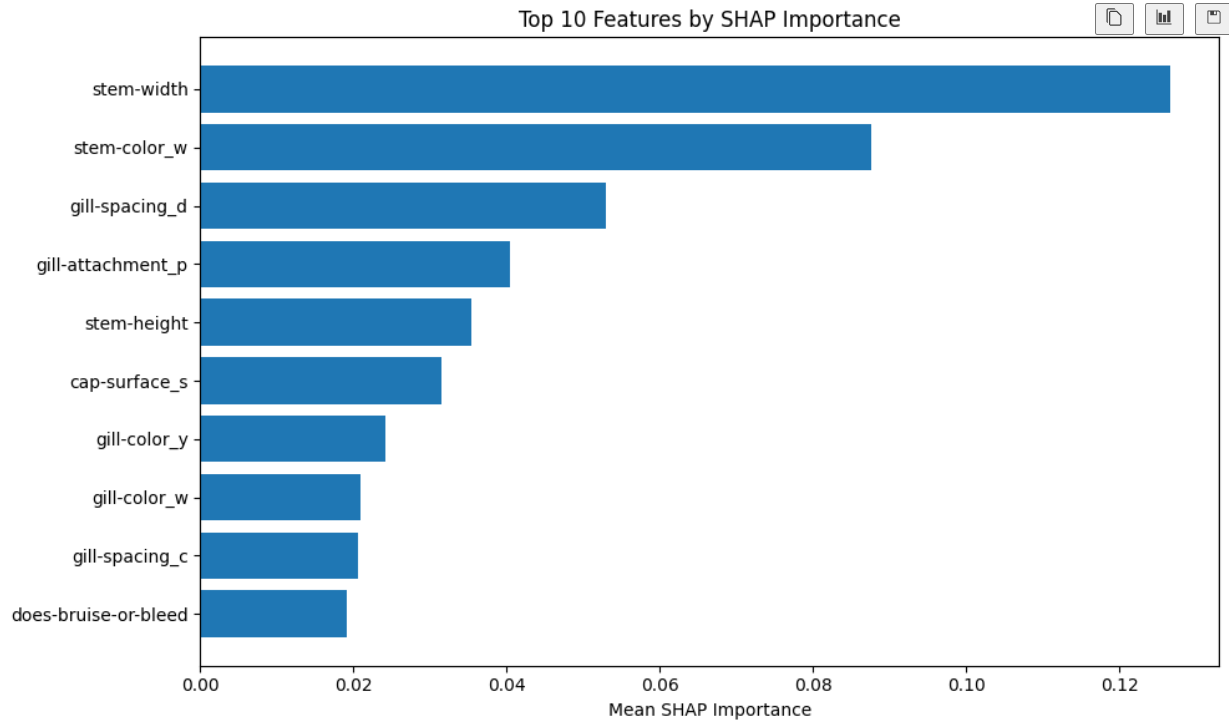<br>
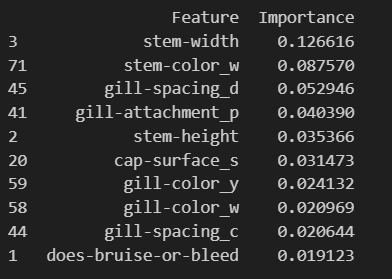<br>
- variables that are not in top 10 will be dropped, this will decreade total number of variables
- cap-surface, gill-attachment, gill-spacing variables are in top 10, though not all the values there. I will keep these variables.
- ring type not in top 10, can be dropped.
#### After that will be possible to check again Shap to have more insides.
#### VFI test:<br>[image-3.png](attachment:image-3.png)<br>
#### Here are 95 variable (dataset after encoding), not possible to evaluate redundancy.<br>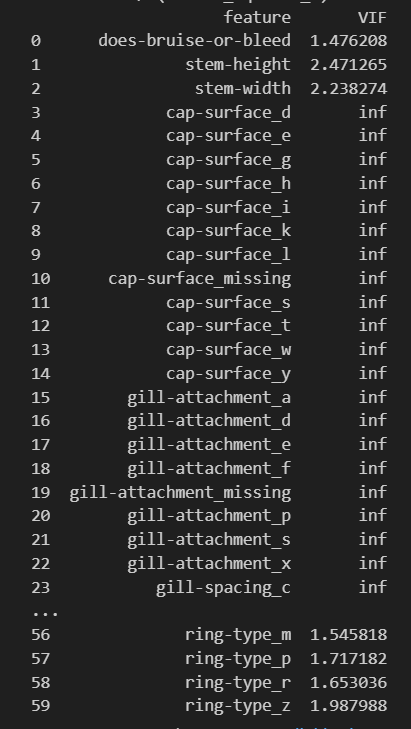<br> Here dataset consists 53 variables (this dataset with reduced number of variables, that I made after Shap). Many variables have infinit score, otherwise other variables that possible to see have little redundancy.


### **Distributions and imbalances**

#### We will analyze the distribution and balance of variables using the original, non-encoded dataset.For example, instead of analyzing encoded features like cap-shape_b, cap-shape_c, we will examine the raw categorical variable cap-shape to understand its value distribution before one-hot encoding. These variables will be checked further:
- class<br>
#### Acceptable distribution<br>
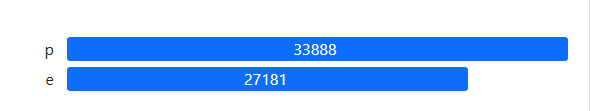<br>
- stem-width<br>
#### This distribution mirrors the target. It is a valid and informative variable and top Shap feature<br>
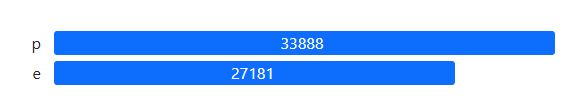<br>
- stem-color <br>
#### Imbalanced, few categories dominate. Possible to use one-hot encoding or combine rare categories.<br>
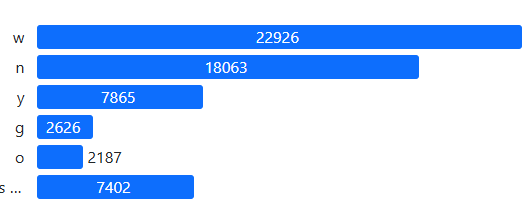<br>
- gill-spacing<br>
#### gill-spacing is important variable based on Snap, so recommended to keep and encode missing as a separate category<br>
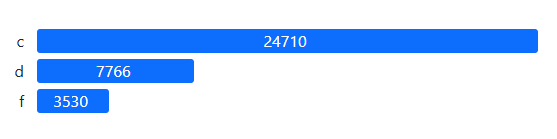<br>
- gill-attachment<br>
#### Moderate balance. Encode missing as a category as Snap shows that gill-attachment_d is quite important<br>
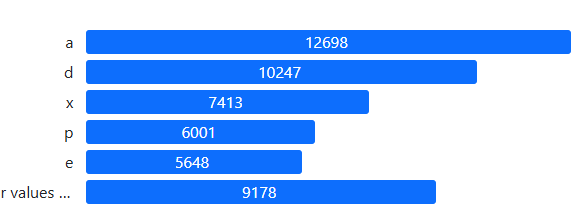<br>
- stem-height  <br>
#### Positively skewed distribution. Consider log transform<br>
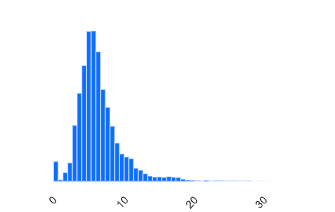<br>
- cap-surface <br>
#### Encode missing as a category as Shap shows some importance. Several categories present, with dominant ones.<br>
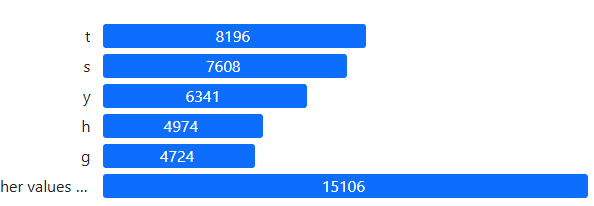<br>
- gill-color<br>
#### Some imbalance ( w = 18,521, others 4–9k). Can be used one-hot encoding or merge rare classses<br>
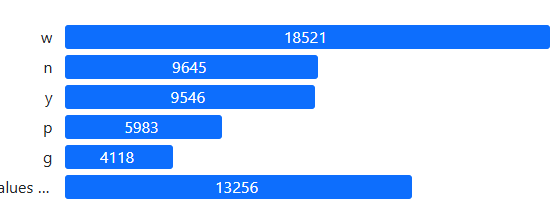<br>
- gill-spacing<br>
#### Has missing values, Encode missing as separate category<br>
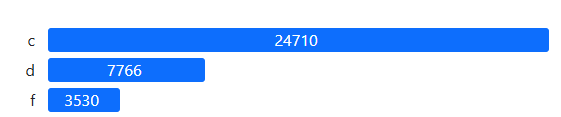<br>
- does-bruise-or-bleed<br>
#### Slight imbalance but can be kept.<br>
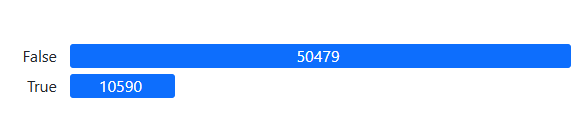<br>


### **Imbalanced categorical combinations**
#### Apriori test: 
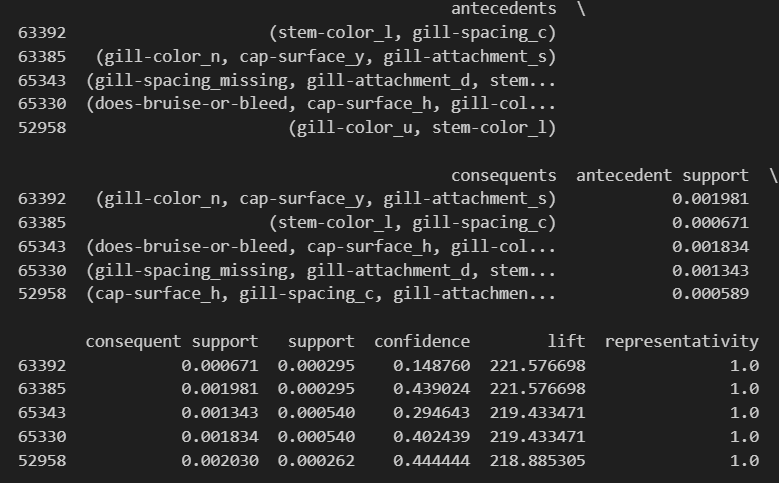<br>
- if stem-color_l and gill-spacing_c → gill-color_n, cap-surface_y, gill-attachment_s - has very high lift = 221.58, meaning strong but rare rule, high lift shows strong association.
- there are high lift values also for these rules: If does-bruise-or-bleed, cap-surface_h, gill-color_o →
gill-spacing_missing, gill-attachment_d, stem-color_u and If gill-color_u, stem-color_l →
cap-surface_h, gill-spacing_c, gill-attachment_d. THese rules have als oquite a high confidence, meaning rules are highly predictive but they are rare, beacuse support for these rules are low 0.000540, or about that. 

### **Noise / outliers**

#### As this dataset has so many variables, I inspected reduced mushroom dataset where I kept only important variable. So, according to the MAD and Isolation Forest we have these plots:<br>
- Most outliers are located at higher stem-width values (> 22)
- Outliers appear in both class = 0 and class = 1, though slightly more in class = 1 (poisonous).
- There is a clear concentration of inliers in the low stem-width range
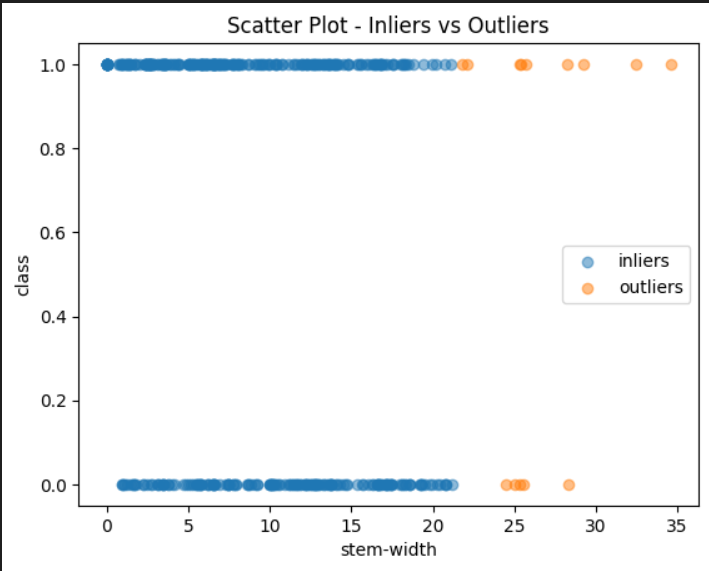<br>
- Isolation Forest flagged a broader range of values as outliers, even some that fall well within the normal stem-width range
- Many of these flagged outliers do not appear visually extreme
- Only a few very large stem-width values have outliers
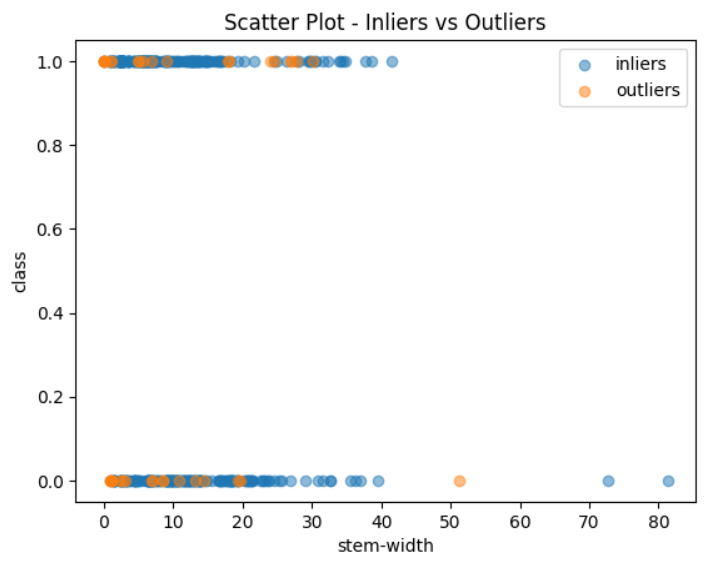<br>

### **SHAP** 
#### Below is the Snap result:
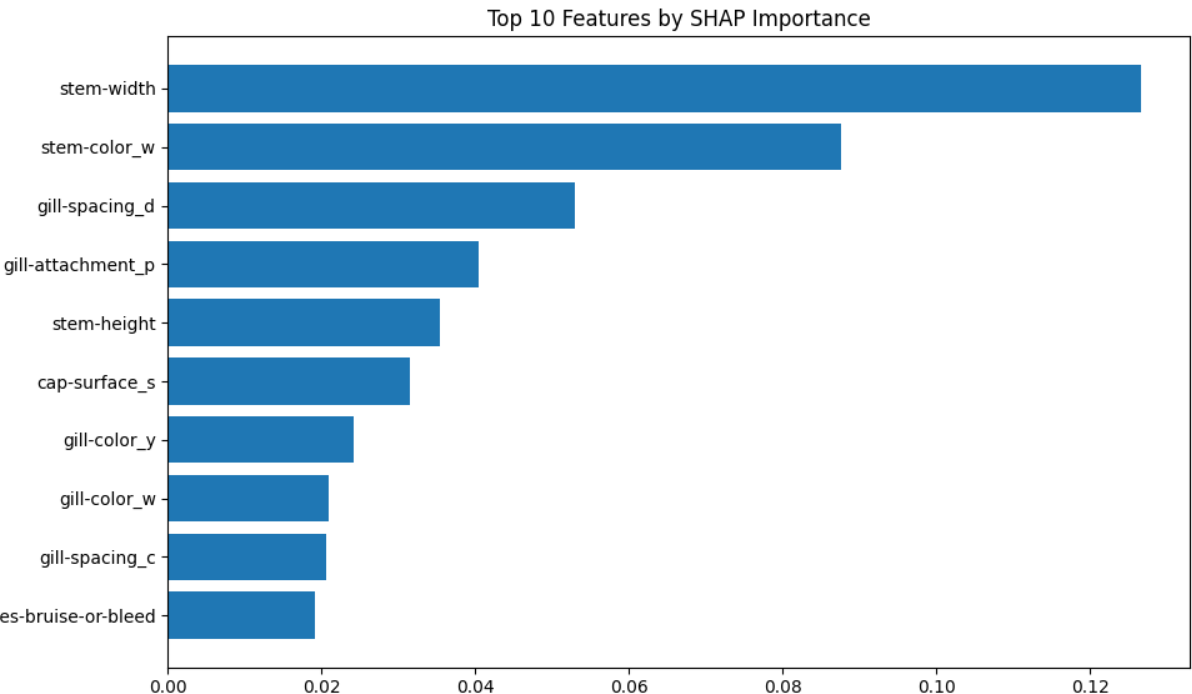<br>
- Shap shows 10 the most important variables that important for class variable prediction
- as this dataset contains so many classification variables, i kept these 10 variables and dropped others. (mushroon_reduced.csv) And i used that dataset in noise detection, outliers detection and  apriory tests. 
- stem-width is the most important variable, low width → likely class 0, high width → likely class 1
- gill-spacing_d and cap-surface_s -> more indicative of class 1 when specific categories are present
- stem-color_w -> When stem-color_w = 0 (not white), more than half are poisonous, when stem-color_w = 1 (white), the majority are edible

### Irregularities in trends / contradictions



#### 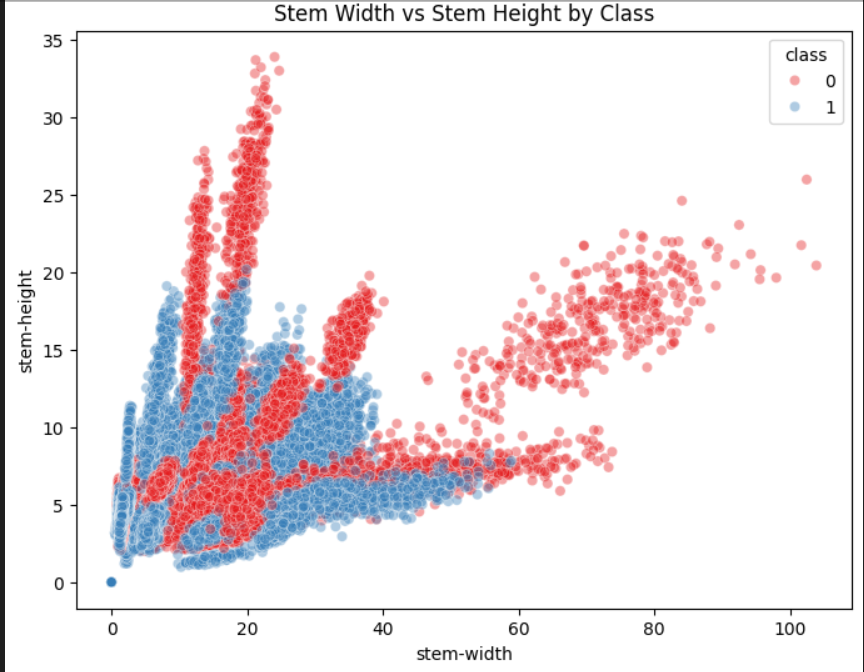<br>We  can see that the dataset contains many overlapping observations between the two classes, especially in the lower and middle paarts of the plot. Class 1 concentrated mostly in "stem-width" 3–40,  "stem-height": 2–18. Class 0:<br> 1. Appears in middle cluster overlapping with class 1.<br> 2. Tall stems (stem-height up to 35)<br>3. Very wide stems (stem-width up to 100). So, we can conclude that the dataset contains significant class overlap. Class 1 tends to have shorter stems and moderate widths. Class 0 appears in multiply clusters and shows much larger variation. High values of "stem-width" and "stem-height" have class 0.<br> 
#### 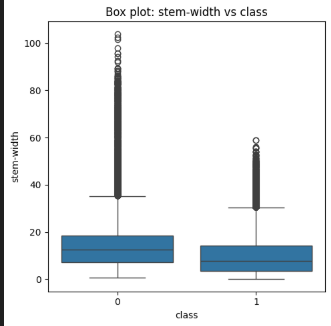<br>Class 0 has higher median stem width, has larger spread and many extreme outliers.<br>Class 1 has lower median, narrower distribution and fewer extreme values.<br>
#### 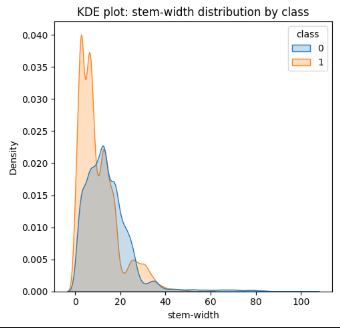<br>Class 1 - strong peak at low stem-width values (3-6).

Density quickly drops after ~20.

### **Summary of key points:**

#### The target variable "class" (edible/poisonous) is relatively well-balanced, which is good for classification performance. No class-weight adjustments are strictly necessary. There were initially many categorical variables, some with high cardinality and missing values. Several variables were dropped due to:
- High missingness (e.g., stem-root, veil-color, spore-print-color, stem-surface)
- Low biological relevance to toxicity
#### For variables with moderate missingness (e.g., cap-surface, gill-attachment, gill-spacing, ring-type), missing values were imputed with a "missing" category to retain data.
####  Using SHAP analysis, the most important features influencing mushroom toxicity were:
- stem-width - thicker stems linked to poisonous mushrooms
- stem-height - moderate impact, possibly tied to maturity of species
- c and gill-spacing_c -> gill-spacing_c = 1 is mildly indicative of poisonous mushrooms, gill-spacing_d = 1 leans slightly edible, but it’s not strongly predictive. Neither are perfect indicators on their own, but might be more useful in combination.
- stem-color_w - White stem color (stem-color_w = 1) is slightly more indicative of edible mushrooms (class 0)
- cap-surface_s and gill-attachment_p - structural surface characteristics contributing to prediction
#### These variables were retained. Others with little to no predictive value were removed.
#### Due to the large number of one-hot encoded categorical variables, many combinations do not exist in the dataset. For example, combinations like cap-surface_k, ring-type_z, or rare habitat-season pairs are either absent or appear only once. It may be helpful to merge rare categories where biologically appropriate. IN VIF test no strong multicollinearity were detected.
#### Apriori analysis found rare but highly predictive rules. Very high confidence and lift, but low support.
#### SHAP was used to reduce the number of features to the top 10 most important. Only numeric and relevant variables were kept to enhance model interpretability and reduce noise.